# Capstone: Bayesian Optimisation of Eight Black-Box Functions

This notebook is my working pipeline for the capstone challenge. The aim is to **maximise eight unknown functions** (2D to 8D) using **one query per function per week**.

**My approach and weekly workflow**
1. Setup and configuration
2. Weekly history: every query submitted and every result received
3. Data loading
4. Exploratory analysis
5. Surrogate model: Gaussian Process
6. Acquisition functions and candidate search
7. Per-function strategy: considerations and settings
8. Primary GP proposals and model checks
9. Method comparison: GP, TPE, Random Forest, TuRBO and trend-following
10. Final selection and portal submission
11. Progress tracking
12. Conclusions and weekly reflection

## My approach and weekly workflow

### The eight functions

| Function | Input | Descriptions of sample applications |
| :------: | :----------: | :---------- |
| 1            | 2D array (10,2)     | Detect likely contamination sources in a two-dimensional area, such as a radiation field, where only proximity yields a non-zero reading. The system uses Bayesian optimisation to tune detection parameters and reliably identify both strong and weak sources. |
| 2            | 2D array (10,2)     | Imagine a black box, or a mystery ML model, that takes two numbers as input and returns a log-likelihood score. Your goal is to maximise that score, but each output is noisy, and depending on where you start, you might get stuck in a local optimum. To tackle this, you use Bayesian optimisation, which selects the next inputs based on what it has learned so far. It balances exploration with exploitation, making it well suited to noisy outputs and complex functions with many local peaks. |
| 3            | 3D array (15,3)     | You’re working on a drug discovery project, testing combinations of three compounds to create a new medicine. Each experiment is stored in initial_inputs.npy as a 3D array, where each row lists the amounts of the three compounds used. After each experiment, you record the number of adverse reactions, stored in initial_outputs.npy as a 1D array. Your goal is to minimise side effects; in this competition, it is framed as maximisation by optimising a transformed output (e.g. the negative of side effects).  |
| 4            | 4D array (30,4)     | Address the challenge of optimally placing products across warehouses for a business with high online sales, where accurate calculations are costly and only feasible biweekly. To speed up decision-making, an ML model approximates these results within hours. The model has four hyperparameters to tune, and its output reflects the difference from the expensive baseline. Because the system is dynamic and full of local optima, it requires careful tuning and robust validation to find reliable, near-optimal solutions. |
| 5            | 4D array (20,4)     | You’re tasked with optimising a four-variable black-box function that represents the yield of a chemical process in a factory. The function is typically unimodal, with a single peak where yield is maximised. Your goal is to find the optimal combination of chemical inputs that delivers the highest possible yield, using systematic exploration and optimisation methods. |
| 6            | 5D array (20,5)     | You’re optimising a cake recipe using a black-box function with five ingredient inputs, for example flour, sugar, eggs, butter and milk. Each recipe is evaluated with a combined score based on flavour, consistency, calories, waste and cost, where each factor contributes negative points as judged by an expert taster. This means the total score is negative by design. To frame this as a maximisation problem, your goal is to bring that score as close to zero as possible or, equivalently, to maximise the negative of the total sum. |
| 7            | 6D array (30,6)     | You’re tasked with optimising an ML model by tuning six hyperparameters, for example learning rate, regularisation strength or number of hidden layers. The function you’re maximising is the model’s performance score (such as accuracy or F1), but since the relationship between inputs and output isn’t known, it’s treated as a black-box function. Because this is a commonly used model, you might benefit from researching best practices or literature to guide your initial search space. Your goal is to find the combination of hyperparameters that yields the highest possible performance. |
| 8            | 8D array (40,8)     | You’re optimising an eight-dimensional black-box function, where each of the eight input parameters affects the output, but the internal mechanics are unknown. Your objective is to find the parameter combination that maximises the function’s output, such as performance, efficiency or validation accuracy. Because the function is high-dimensional and likely complex, global optimisation is hard, so identifying strong local maxima is often a practical strategy. For example, imagine you’re tuning an ML model with eight hyperparameters: learning rate, batch size, number of layers, dropout rate, regularisation strength, activation function (numerically encoded), optimiser type (encoded) and initial weight range. Each input set returns a single validation accuracy score between 0 and 1. Your goal is to maximise this score. |

### How I see the problem
I am trying to find the maximum of eight functions that I can't see. I only get one evaluation per function per week, so every query is expensive, much like a real experiment, a slow simulation or a long model-training run. That rules out anything that needs many evaluations, such as grid search, genetic algorithms or CMA-ES. Instead, I spend my effort **between** queries: modelling what I already know and deciding carefully where to look next.

### My guiding principles
1. **Look at the data before modelling it.** Every week I start with plots and simple statistics: correlations and a straight-line fit. This tells me what shape each function might have and gives me a baseline to check the more complex models against.
2. **Use a model that knows what it doesn't know.** My main tool is a **Gaussian Process** surrogate. It gives both a prediction and an uncertainty, and I need both to trade off exploring against exploiting.
3. **Treat each function on its own terms.** The eight functions differ: a flat radiation field, a noisy log-likelihood, a unimodal chemical yield, an 8D hyperparameter space. Each description and dataset sets its own output transform, acquisition function, exploration level and trust region (section 7).
4. **Test the method, not only the point.** Relying on one model is risky with 10–40 observations, so every week I run **five different strategies** on every function (section 9):
   - **GP + EI or UCB:** my primary Bayesian optimisation method, with calibrated uncertainty
   - **TPE (Tree-structured Parzen Estimator):** the standard method in hyperparameter-tuning tools. It models the density of "good" and "bad" inputs rather than the output itself
   - **Random Forest (the idea behind SMAC):** a tree-ensemble surrogate that copes with thresholds, jumps and discrete-like inputs, which a GP handles poorly
   - **TuRBO-style trust region:** GP search in a box around my best point that **grows after successes and shrinks after failures**
   - **Trend-following:** a step up the gradient of a linear fit. It is the simplest possible baseline
   
   When the methods **agree**, I can exploit with confidence. When they **disagree**, that tells me the landscape is still uncertain, and I have to decide deliberately which reasoning to trust.
5. **Check whether my model deserves trust.** A leave-one-out test tells me how well the GP predicts points it hasn't seen. If the GP is reliable I follow it. If it isn't, I lean on local, conservative methods or on the consensus of all five.
6. **Move from exploring to exploiting over time, function by function.** Early weeks lean towards exploration. As the data grows, and wherever a function improves, I narrow the search. Where a function stalls for several weeks, I widen it again.

### How I choose the final query each week
For each function, section 10 shows a **recommended** method, based on this rule:
| Situation | What I submit | Why |
|---|---|---|
| The function still has no usable signal (e.g. F1 while it's flat) | GP-pipeline exploration point (maximin) | Nothing to model yet, so fill the space |
| GP is reliable (LOO Spearman ≥ 0.7) | GP proposal | Trust the model that has shown it predicts well |
| GP is less reliable, but the five methods broadly agree | Consensus (medoid) proposal | Several independent reasonings point the same way |
| GP is less reliable and the methods disagree | TuRBO proposal | Stay close to what has worked, with a search box that adapts to success |

The recommendation is a starting point, not an autopilot. I review each one against the plots and my notes, override it in `SELECT` when I have a reason, and record that reason in my reflection.

### My weekly workflow
1. **Record the results.** When the portal returns outputs, I enter each `y` in `HISTORY` (section 2), replacing `None`.
2. **Move the week on.** I increase `CURRENT_WEEK` (section 1).
3. **Review the data.** I re-read the exploratory plots and the progress chart (sections 4 and 11). Did last week's query improve the best? Did it confirm or contradict what the model predicted?
4. **Adjust the strategy.** In `CONFIG` (section 7) I change what the results call for: reduce κ or ξ where I'm now exploiting, add or shrink trust regions, or switch acquisition function.
5. **Run all cells.** This produces the GP proposals, the model checks and the five-method comparison.
6. **Decide.** In section 10, I review the recommended method for each function, set `SELECT`, and note why.
7. **Submit and log.** I copy the eight query strings into the portal, paste the printed `HISTORY` block into section 2 with `y = None`, and keep the saved `week_<N>_queries.csv`.
8. **Reflect.** In section 12, I write that week's reflection: the method, exploration vs exploitation, what the results taught me, how much the methods agreed, and my plan for next week.

## 1. Setup and configuration

In [17]:
import json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, spearmanr
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.linear_model import LinearRegression
warnings.filterwarnings("ignore")
pd.set_option("display.precision", 4); pd.set_option("display.width", 200)

DATA_DIR = Path("../data/bbo")        # folder containing function_1 ... function_8
CURRENT_WEEK = 1                      # week we are generating queries FOR
N_FUNCS = 8
UPPER = 0.999999                      # the submmision portal expects values in [0, 1); clip to 6 dp below 1

# plotting style: recessive axes, one accent colour for data and one for highlights
BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#8a8984"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6,
                     "axes.edgecolor": GREY, "axes.titlesize": 10, "axes.labelsize": 9,
                     "xtick.labelsize": 8, "ytick.labelsize": 8})

## 2. Weekly history

Every submitted query goes here **exactly as submitted** (the hyphen-separated string), along with the returned output. I will use `None` for outputs I'm still waiting on: those points are shown but left out of model fitting.

This cell is the single source of truth for everything added after the initial data.

In [38]:
HISTORY = {
    1: {  # Week 1: submitted, outputs pending
        1: ("0.419675-0.463269", None),
        2: ("0.963166-0.929385", None),
        3: ("0.233668-0.244902-0.000006", None),
        4: ("0.463911-0.402868-0.364200-0.420348", None),
        5: ("0.100499-0.668722-0.946097-0.999999", None),
        6: ("0.423548-0.129091-0.738806-0.897785-0.000000", None),
        7: ("0.000000-0.566788-0.415090-0.175728-0.355442-0.779021", None),
        8: ("0.052325-0.141964-0.124313-0.014745-0.921651-0.374929-0.039243-0.262463", None),
    },
    # 2: { 1: ("...", None), ... },
}

def parse_query(s):
    return np.array([float(v) for v in s.split("-")])

def fmt_query(x):
    return "-".join(f"{v:.6f}" for v in np.clip(x, 0.0, UPPER))

rows = [dict(week=w, function=f, query=q, y=y) for w, d in HISTORY.items() for f, (q, y) in d.items()]
pd.DataFrame(rows).pivot(index="function", columns="week", values="y") if rows else "no history yet"

week,1
function,
1,None
2,None
3,None
4,None
5,None
6,None
7,None
8,None


## 3. Load data

Combine the initial `.npy` data with every weekly result received so far. Each function's inputs are checked for the right dimension and for the [0, 1] range.

In [46]:
def load_function(i):
    X = np.load(DATA_DIR / f"function_{i}" / "initial_inputs.npy")
    y = np.load(DATA_DIR / f"function_{i}" / "initial_outputs.npy")
    src = ["initial"] * len(y)
    pending = []
    for w in sorted(HISTORY):
        if i not in HISTORY[w]:
            continue
        q, yv = HISTORY[w][i]
        x = parse_query(q)
        assert len(x) == X.shape[1], f"F{i} week {w}: expected {X.shape[1]} values, got {len(x)}"
        if yv is None:
            pending.append((w, x))
        else:
            X = np.vstack([X, x]); y = np.append(y, float(yv)); src.append(f"week {w}")
    assert X.min() >= 0 and X.max() <= 1, f"F{i}: inputs outside [0,1]"
    return dict(X=X, y=y, src=np.array(src), pending=pending, d=X.shape[1])

DATA = {i: load_function(i) for i in range(1, N_FUNCS + 1)}

summary = pd.DataFrame([{
    "function": i, "dims": D["d"], "n_obs": len(D["y"]),
    "n_weekly": int((D["src"] != "initial").sum()), "pending": len(D["pending"]),
    "y_min": D["y"].min(), "y_median": np.median(D["y"]), "y_max": D["y"].max(),
    "best_from": D["src"][D["y"].argmax()],
    "best_x": np.round(D["X"][D["y"].argmax()], 3).tolist(),
} for i, D in DATA.items()]).set_index("function")
summary

,dims,n_obs,n_weekly,pending,y_min,y_median,y_max,best_from,best_x
function,,,,,,,,,
1,2,10,0,1,-0.0036,6.7937e-80,7.7109e-16,initial,"[0.731, 0.733]"
2,2,10,0,1,-0.0656,2.2979e-01,6.1121e-01,initial,"[0.703, 0.927]"
3,3,15,0,1,-0.3989,-1.0597e-01,-3.4835e-02,initial,"[0.493, 0.612, 0.34]"
4,4,30,0,1,-32.6257,-1.6040e+01,-4.0255e+00,initial,"[0.578, 0.429, 0.426, 0.249]"
5,4,20,0,1,0.1129,6.3948e+01,1.0889e+03,initial,"[0.224, 0.846, 0.879, 0.879]"
6,5,20,0,1,-2.5712,-1.4464e+00,-7.1426e-01,initial,"[0.728, 0.155, 0.733, 0.694, 0.056]"
7,6,30,0,1,0.0027,7.8631e-02,1.3650e+00,initial,"[0.058, 0.492, 0.247, 0.218, 0.42, 0.731]"
8,8,40,0,1,5.5922,7.8891e+00,9.5985e+00,initial,"[0.056, 0.066, 0.023, 0.039, 0.404, 0.801, 0.4..."


## 4. Exploratory analysis

Before fitting anything, look at the data:
- **2D functions (F1, F2):** a scatter of the observed points coloured by output.
- **Every function:** output against each input separately, which shows the obvious one-dimensional trends.
- **Signal checks:** the Spearman correlation between each input and the output, and how much a straight-line fit explains (R²). A high linear R² means the function behaves much like a slope over the region sampled so far.

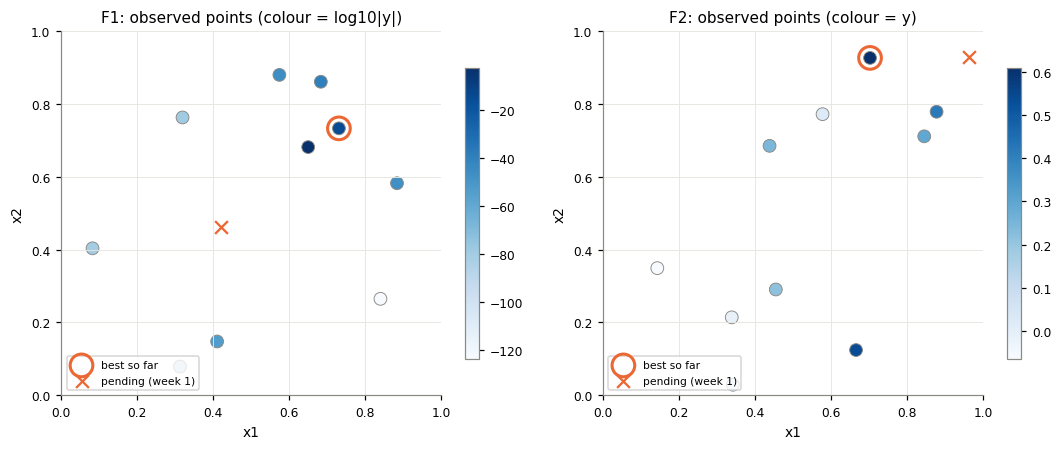

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, i in zip(axes, [1, 2]):
    D = DATA[i]
    y = D["y"]
    # F1 values span ~1e-124 .. 1e-3: colour by log10|y| (magnitude = closeness to a source)
    c = np.log10(np.abs(y) + 1e-300) if i == 1 else y
    sc = ax.scatter(D["X"][:, 0], D["X"][:, 1], c=c, cmap="Blues", s=70, edgecolor=GREY, linewidth=0.6)
    b = D["X"][y.argmax()]
    ax.scatter(*b, s=220, facecolor="none", edgecolor=ORANGE, linewidth=2, label="best so far")
    for w, x in D["pending"]:
        ax.scatter(*x, marker="x", s=70, color=ORANGE, label=f"pending (week {w})")
    ax.set(xlim=(0, 1), ylim=(0, 1), xlabel="x1", ylabel="x2",
           title=f"F{i}: observed points" + (" (colour = log10|y|)" if i == 1 else " (colour = y)"))
    plt.colorbar(sc, ax=ax, shrink=0.8); ax.legend(fontsize=7, loc="lower left")
plt.tight_layout(); plt.show()

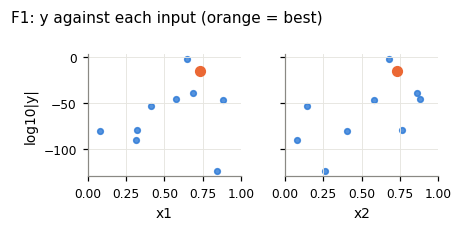

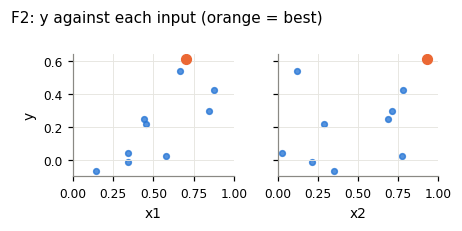

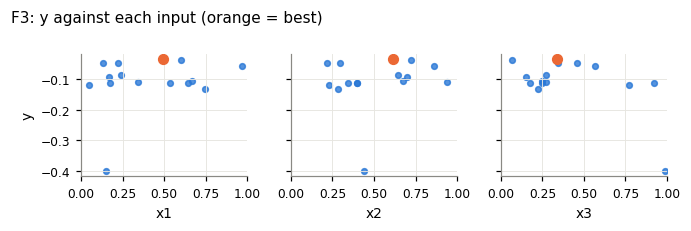

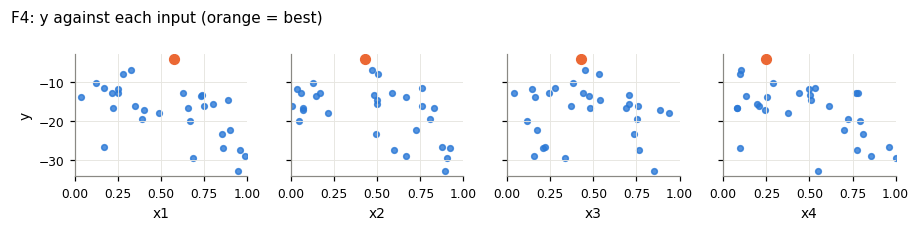

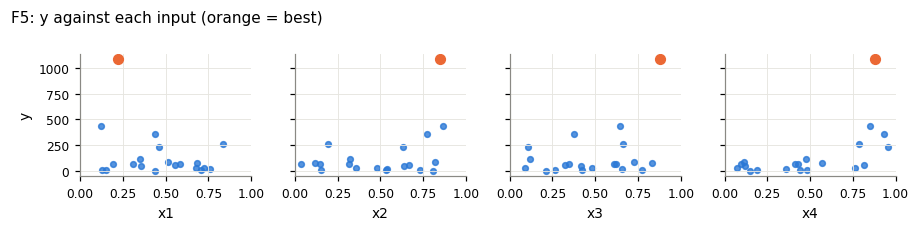

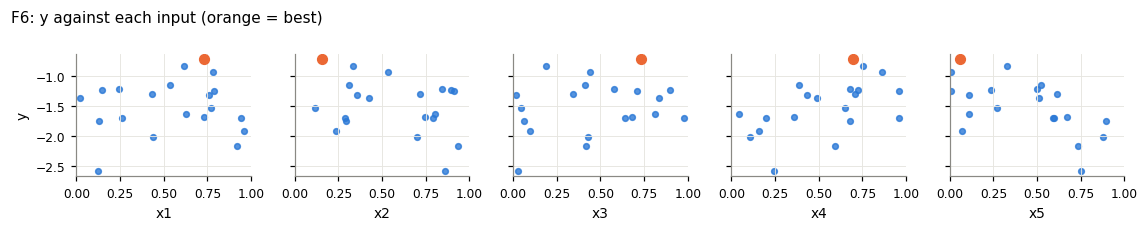

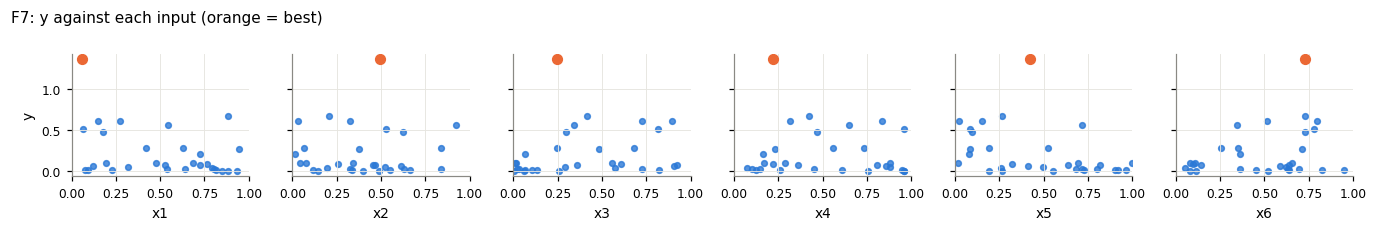

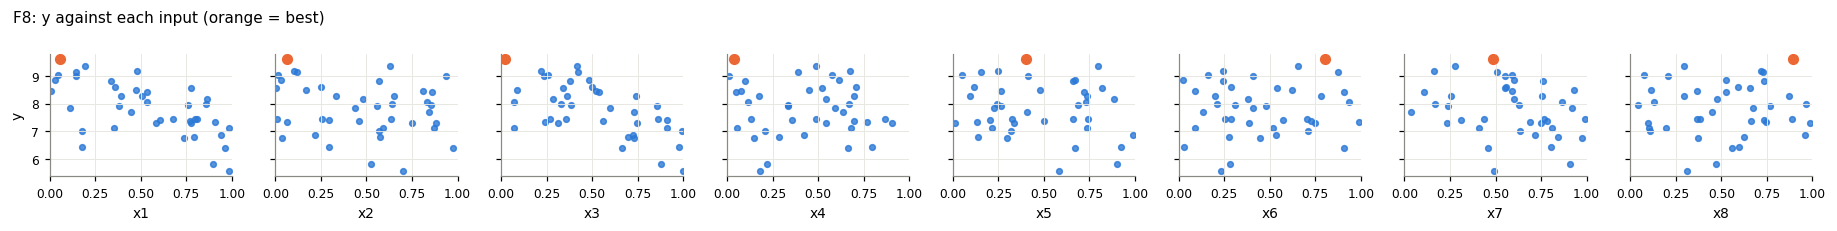

In [21]:
for i, D in DATA.items():
    d = D["d"]; X, y = D["X"], D["y"]
    fig, axes = plt.subplots(1, d, figsize=(2.1 * d, 2.1), sharey=True)
    axes = np.atleast_1d(axes)
    yy = np.log10(np.abs(y) + 1e-300) if i == 1 else y
    for k in range(d):
        ax = axes[k]
        ax.scatter(X[:, k], yy, s=14, color=BLUE, alpha=0.8)
        ax.scatter(X[y.argmax(), k], yy[y.argmax()], s=40, color=ORANGE, zorder=3)
        ax.set_xlim(0, 1); ax.set_xlabel(f"x{k+1}")
    axes[0].set_ylabel("log10|y|" if i == 1 else "y")
    fig.suptitle(f"F{i}: y against each input (orange = best)", fontsize=10, x=0.01, ha="left")
    plt.tight_layout(); plt.show()

In [22]:
sig = []
for i, D in DATA.items():
    X, y = D["X"], D["y"]
    yt = np.log(np.maximum(y, 1e-9)) if i == 5 else y
    r2 = LinearRegression().fit(X, yt).score(X, yt)
    rho = [spearmanr(X[:, k], y).correlation for k in range(D["d"])]
    sig.append({"function": i, "linear_R2": r2,
                **{f"rho_x{k+1}": r for k, r in enumerate(rho)}})
pd.DataFrame(sig).set_index("function").round(2)

,linear_R2,rho_x1,rho_x2,rho_x3,rho_x4,rho_x5,rho_x6,rho_x7,rho_x8
function,,,,,,,,,
1,0.04,0.36,0.68,NaN,NaN,NaN,NaN,NaN,NaN
2,0.57,0.82,0.38,NaN,NaN,NaN,NaN,NaN,NaN
3,0.37,0.10,0.31,-0.23,NaN,NaN,NaN,NaN,NaN
4,0.58,-0.57,-0.47,-0.16,-0.45,NaN,NaN,NaN,NaN
5,0.53,-0.14,0.15,0.27,0.58,NaN,NaN,NaN,NaN
6,0.65,-0.01,-0.18,0.23,0.55,-0.62,NaN,NaN,NaN
7,0.35,-0.29,-0.09,0.32,-0.09,-0.45,0.19,NaN,NaN
8,0.90,-0.61,-0.23,-0.58,-0.11,-0.12,0.01,-0.3,0.05


**Observations from the initial data** (update as the data grows):
- **F1:** almost every output is about 0 (between 1e-124 and 1e-15). The only noticeable reading is -0.0036 at (0.65, 0.68). This fits the description: a source that is only detectable close up. On the log-magnitude plot, readings grow steadily towards the cluster at (0.65–0.73, 0.68–0.88), so a source probably lies near there. The raw values are still too flat for a GP, so Week 1 explores the empty centre. That area is the fallback for exploitation.
- **F2:** moderate spread. The best values are at x1 ≈ 0.67–0.70. The description warns of noise and local optima.
- **F3:** all outputs are negative (it is a negated count of side effects). x3 looks the most important input, and high x3 is bad.
- **F4:** the best point is central, around (0.58, 0.43, 0.43, 0.25), and outputs drop steeply towards the edges. This suggests a peaked function.
- **F5:** outputs span four orders of magnitude (0.1 to 1089), which calls for a log transform. Yield rises with x3 and x4. The description says the function is unimodal.
- **F6:** all scores are negative by design. Better recipes have low x5 and higher x3 and x4.
- **F7:** a single standout result of 1.36, about twice the next best. The function is probably sharply peaked.
- **F8:** a straight-line fit explains about 90% of the variance. Low x1, x3 and x7 are good.

## 5. Surrogate model: Gaussian Process

**Why a GP?** With 10–40 points, we need a model that gives both a prediction **and its uncertainty**. Acquisition functions trade those two off against each other. A GP does this in a principled way and works well with small data.

**Kernel choices:**
- **Matern ν = 5/2** instead of RBF. It assumes a less smooth function, which is more realistic for black boxes.
- **ARD (a separate length-scale for each input).** Each learned length-scale works as a rough importance measure. A short length-scale means the output changes quickly with that input. A length-scale at the upper bound (10) means the input barely matters.
- **White noise term.** This handles noisy functions (F2 especially) and keeps the fit numerically stable.
- `normalize_y=True` and 15 optimiser restarts, to make the hyperparameter fit more robust.

**Output transforms:** `log` for F5 (a huge range, and yield is positive). Other functions use raw outputs.

**Model check:** leave-one-out (LOO) cross-validation. Refit without each point in turn and predict it. A Spearman correlation between the LOO predictions and the true values near 0, or below 0, means the GP is not yet trustworthy. Lean more on exploring, or on simple trend models, until it is.

In [23]:
def transform(y, tf):
    return np.log(np.maximum(y, 1e-6)) if tf == "log" else y

def inverse(v, tf):
    return np.exp(v) if tf == "log" else v

def fit_gp(X, yt, restarts=15):
    d = X.shape[1]
    kernel = C(1.0) * Matern(length_scale=np.full(d, 0.3), length_scale_bounds=(0.02, 10), nu=2.5) \
             + WhiteKernel(1e-3, (1e-6, 1e-1))
    return GaussianProcessRegressor(kernel, normalize_y=True, n_restarts_optimizer=restarts,
                                    random_state=0).fit(X, yt)

def loo_spearman(X, yt):
    preds = []
    for j in range(len(yt)):
        m = np.ones(len(yt), bool); m[j] = False
        preds.append(fit_gp(X[m], yt[m], restarts=2).predict(X[j:j+1])[0])
    return spearmanr(preds, yt).correlation

## 6. Acquisition functions and candidate search

| Acquisition | Formula | Behaviour |
|---|---|---|
| **EI** (Expected Improvement) | $E[\max(f(x) - f^* - \xi, 0)]$ | Balanced. Larger $\xi$ means more exploration |
| **UCB** (Upper Confidence Bound) | $\mu(x) + \kappa\,\sigma(x)$ | $\kappa$ sets the exploration level directly. Robust for noisy and multi-modal functions |
| **PI** (Probability of Improvement) | $P(f(x) > f^* + \xi)$ | Greedy. Only useful for late fine-tuning |

**Candidate search.** Instead of running a gradient optimiser on the acquisition surface, score a large candidate set:
- 40,000 points drawn uniformly from $[0,1]^d$, for global coverage
- Gaussian perturbations (σ = 0.03 and 0.1) around the top three observations, for local refinement

**Trust region (optional).** Keep candidates inside a box of ±`tr` around the current best. This stops the GP from extrapolating into corners with no data, which is a known failure mode in higher dimensions with few points.

**Pure exploration mode.** When a function carries no usable signal (F1), choose the point furthest from every observation (maximin). This fills the space and gives the best chance of finding a region with signal.

In [24]:
def acquisition(mu, sd, y_best, kind, xi=0.01, kappa=2.0, y_scale=1.0):
    sd = np.maximum(sd, 1e-12)
    if kind == "ucb":
        return mu + kappa * sd
    imp = mu - y_best - xi * y_scale
    z = imp / sd
    if kind == "pi":
        return norm.cdf(z)
    return imp * norm.cdf(z) + sd * norm.pdf(z)          # EI

def make_candidates(X, y, rng, n=40000):
    d = X.shape[1]
    glob = rng.uniform(0, 1, (n, d))
    top = X[np.argsort(-y)[:3]]
    loc = np.vstack([t + rng.normal(0, s, (n // 6, d)) for t in top for s in (0.03, 0.1)])
    return np.clip(np.vstack([glob, loc]), 0, UPPER)

def maximin_point(X, rng, lo=0.0, hi=1.0, n=200000):
    cand = rng.uniform(lo, hi, (n, X.shape[1]))
    dist = np.min(np.linalg.norm(cand[:, None] - X[None], axis=2), axis=1)
    return cand[dist.argmax()], dist.max()

## 7. Per-function strategy

Each function has its own settings. **This is the cell to review and edit every week.** The rationale column records *why* each setting was chosen, which feeds the reflection.

| F | Dim | Context | Key considerations | Week 1 setting |
|---|---|---|---|---|
| 1 | 2 | Radiation/contamination source | Signal only near a source, so almost all readings are 0. There may be more than one source (strong and weak). The GP is useless on a flat signal. | **Explore**: maximin in [0.1, 0.9]². Switch to a GP once any |y| > 0.01 appears. |
| 2 | 2 | Noisy log-likelihood | Noisy outputs and local optima. Don't over-trust single observations. | **UCB, κ = 2** |
| 3 | 3 | Drug side-effects (negated) | x3 dominates. The optimum may be on the boundary (x3 → 0). | **EI, ξ = 0.01** |
| 4 | 4 | Warehouse ML model | "Dynamic, many local optima". A clear central incumbent with steep drops at the edges. | **EI, ξ = 0.01** (exploit near the centre) |
| 5 | 4 | Chemical yield | Unimodal. Output range is 0.1–1089, so model log(y). Unconstrained EI extrapolated to a data-free corner. | **EI on log(y), trust region ±0.2** |
| 6 | 5 | Cake recipe (negative score) | Aim for 0. A consistent trend (low x5, high x3 and x4). | **EI, ξ = 0.01** |
| 7 | 6 | ML hyperparameters | One outstanding point, so probably a narrow peak. Some inputs appear irrelevant. | **UCB, κ = 2** |
| 8 | 8 | 8-D hyperparameters | High-dimensional. A linear trend explains 90%. Aim for a strong local maximum. | **UCB, κ = 2** |

**General schedule:** explore more in early weeks and exploit more later. As a rough guide, reduce κ from about 2.5 to about 1, reduce ξ from 0.05 to 0.001, and shrink trust regions as the weeks go on. Adjust each function to its own results: if a query improves the best, exploit around it; if several queries fail in a row, explore more widely.

In [25]:
CONFIG = {
    1: dict(mode="explore", lo=0.1, hi=0.9, signal_threshold=1e-2,
            why="Outputs are ~0 everywhere; fill the space until a non-trivial reading appears."),
    2: dict(tf="none", acq="ucb", kappa=2.0,
            why="Noisy and multi-modal; UCB explores the uncertain regions."),
    3: dict(tf="none", acq="ei", xi=0.01,
            why="x3 dominates; EI follows the trend towards low x3."),
    4: dict(tf="none", acq="ei", xi=0.01,
            why="Clear central peak; EI refines near the incumbent."),
    5: dict(tf="log", acq="ei", xi=0.01, tr=0.2,
            why="Unimodal, huge range: log(y); trust region prevents corner extrapolation."),
    6: dict(tf="none", acq="ei", xi=0.01,
            why="Consistent trend; EI balanced."),
    7: dict(tf="none", acq="ucb", kappa=2.0,
            why="Single standout point; UCB probes around it while keeping some exploration."),
    8: dict(tf="none", acq="ucb", kappa=2.0,
            why="High-D, near-linear trend; UCB exploits the trend and explores unimportant dims."),
}
pd.DataFrame(CONFIG).T.fillna("")

,mode,lo,hi,signal_threshold,why,tf,acq,kappa,xi,tr
1,explore,0.1,0.9,0.01,Outputs are ~0 everywhere; fill the space unti...,,,,,
2,,,,,Noisy and multi-modal; UCB explores the uncert...,none,ucb,2.0,,
3,,,,,x3 dominates; EI follows the trend towards low...,none,ei,,0.01,
4,,,,,Clear central peak; EI refines near the incumb...,none,ei,,0.01,
5,,,,,"Unimodal, huge range: log(y); trust region pre...",log,ei,,0.01,0.2
6,,,,,Consistent trend; EI balanced.,none,ei,,0.01,
7,,,,,Single standout point; UCB probes around it wh...,none,ucb,2.0,,
8,,,,,"High-D, near-linear trend; UCB exploits the tr...",none,ucb,2.0,,


## 8. Primary GP proposals and model checks

For each function: fit the GP, score the candidates and select the best one. Then report the prediction, the uncertainty, the distance from the current best (large means exploring, small means exploiting) and the learned length-scales.

The random generator is seeded (42) and the functions run in order, so the results can be reproduced. Week 1 reproduces the queries that were actually submitted.

In [26]:
def propose(i, D, cfg, rng):
    X, y = D["X"], D["y"]
    out = dict(function=i, n_obs=len(y), best_y=y.max())
    # F1-style pure exploration while the signal is flat
    if cfg.get("mode") == "explore" and np.abs(y).max() < cfg.get("signal_threshold", 0):
        x, dmin = maximin_point(X, rng, cfg.get("lo", 0), cfg.get("hi", 1))
        out.update(query=fmt_query(x), x=x, method="maximin", pred_mean=np.nan, pred_sd=np.nan,
                   dist_to_best=np.linalg.norm(x - X[y.argmax()]), lengthscales=None,
                   note=f"flat signal; nearest observation {dmin:.3f} away")
        return out, None
    if cfg.get("mode") == "explore":      # signal found: fall back to a UCB GP
        cfg = dict(tf="none", acq="ucb", kappa=2.5, **{k: v for k, v in cfg.items() if k == "why"})
    yt = transform(y, cfg["tf"])
    gp = fit_gp(X, yt)
    cand = make_candidates(X, y, rng)
    if "tr" in cfg:
        cand = cand[np.all(np.abs(cand - X[y.argmax()]) <= cfg["tr"], axis=1)]
    mu, sd = gp.predict(cand, return_std=True)
    a = acquisition(mu, sd, yt.max(), cfg["acq"], cfg.get("xi", 0.01), cfg.get("kappa", 2.0), np.std(yt))
    j = a.argmax(); x = cand[j]
    out.update(query=fmt_query(x), x=x, method=cfg["acq"].upper() + (f" (TR ±{cfg['tr']})" if "tr" in cfg else ""),
               pred_mean=inverse(mu[j], cfg["tf"]), pred_sd=sd[j],
               dist_to_best=np.linalg.norm(x - X[y.argmax()]),
               lengthscales=np.round(gp.kernel_.k1.k2.length_scale, 3).tolist(), note="")
    return out, gp

rng = np.random.default_rng(42)
RESULTS, MODELS = {}, {}
for i in range(1, N_FUNCS + 1):
    RESULTS[i], MODELS[i] = propose(i, DATA[i], CONFIG[i], rng)

res_df = pd.DataFrame(RESULTS.values()).set_index("function")
res_df[["method", "n_obs", "best_y", "pred_mean", "pred_sd", "dist_to_best", "lengthscales", "note"]]

,method,n_obs,best_y,pred_mean,pred_sd,dist_to_best,lengthscales,note
function,,,,,,,,
1,maximin,10,7.7109e-16,NaN,NaN,0.4119,None,flat signal; nearest observation 0.316 away
2,UCB,10,6.1121e-01,0.3545,0.2076,0.2605,"[0.072, 10.0]",
3,EI,15,-3.4835e-02,-0.0579,0.0842,0.5632,"[10.0, 10.0, 0.084]",
4,EI,30,-4.0255e+00,-1.8882,0.7526,0.2163,"[1.834, 1.623, 1.839, 1.78]",
5,EI (TR ±0.2),20,1.0889e+03,2528.5615,1.6795,0.2571,"[1.977, 0.529, 0.985, 0.755]",
6,EI,20,-7.1426e-01,-0.2322,0.2854,0.3718,"[0.864, 1.638, 2.065, 2.133, 2.173]",
7,UCB,30,1.3650e+00,1.2725,0.1441,0.2132,"[1.059, 10.0, 10.0, 0.362, 0.195, 0.246]",
8,UCB,40,9.5985e+00,10.1938,0.2249,1.0323,"[3.143, 4.39, 2.263, 9.84, 10.0, 4.477, 3.125,...",


### Model reliability (LOO check)
A LOO Spearman correlation of about 0.5 or more means the GP ranks unseen points reasonably well. A value near 0 means the surrogate is weak for that function: treat its suggestions as exploratory, and check them against the trends found in section 4.

In [27]:
loo = {}
for i, D in DATA.items():
    if CONFIG[i].get("mode") == "explore" and np.abs(D["y"]).max() < CONFIG[i].get("signal_threshold", 0):
        loo[i] = np.nan; continue
    loo[i] = loo_spearman(D["X"], transform(D["y"], CONFIG[i].get("tf", "none")))
pd.Series(loo, name="LOO Spearman").round(2).to_frame()

,LOO Spearman
1,NaN
2,0.41
3,0.69
4,0.97
5,0.23
6,0.55
7,0.48
8,0.98


**Week 1 reading of the LOO check:** F4 (0.97) and F8 (0.98) are modelled well, so trust the GP and exploit. F3 (0.69), F6 (0.55), F7 (0.48) and F2 (0.41) are moderate, so keep some exploration. **F5 (0.23) is weak**, which justifies the trust region: a surrogate this unreliable should not be allowed to send the query to a distant corner.

### Length-scales (input relevance)
Shorter bars mean the input matters more. Bars that reach the cap of 10 mean the GP finds the input irrelevant, at least with the data so far.

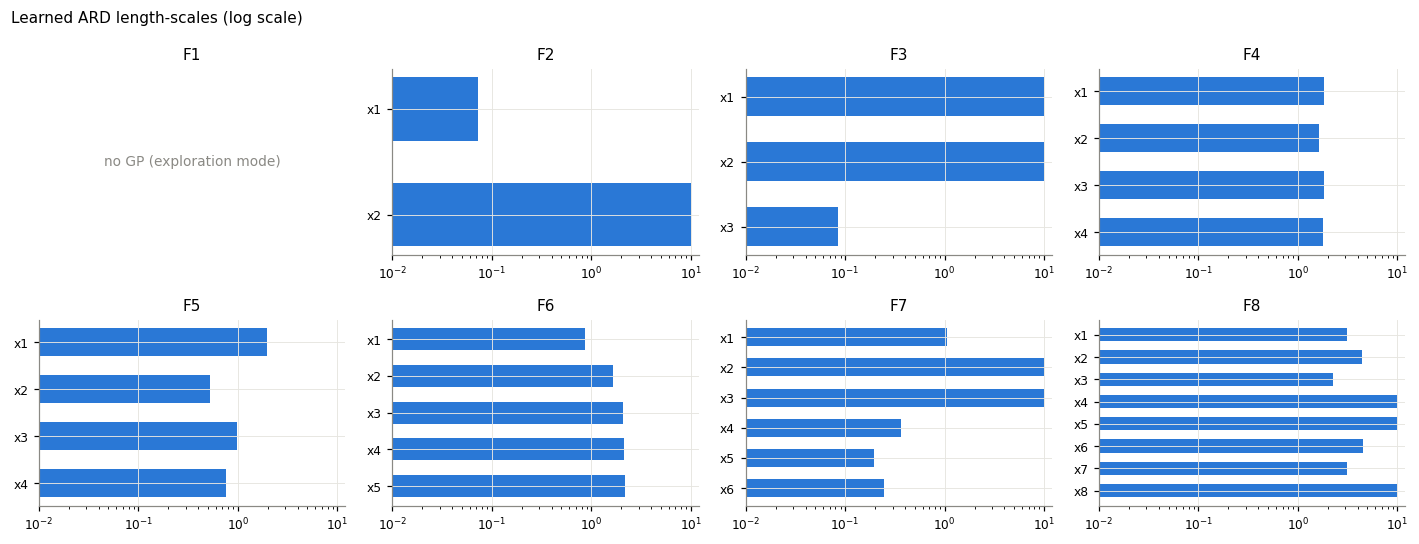

In [28]:
fig, axes = plt.subplots(2, 4, figsize=(13, 5))
for ax, i in zip(axes.ravel(), range(1, 9)):
    ls = RESULTS[i]["lengthscales"]
    if ls is None:
        ax.text(0.5, 0.5, "no GP (exploration mode)", ha="center", va="center", color=GREY, fontsize=9)
        ax.set_axis_off(); ax.set_title(f"F{i}"); continue
    ax.barh([f"x{k+1}" for k in range(len(ls))], ls, color=BLUE, height=0.6)
    ax.set_xscale("log"); ax.set_xlim(0.01, 12); ax.invert_yaxis(); ax.set_title(f"F{i}")
fig.suptitle("Learned ARD length-scales (log scale)", x=0.01, ha="left", fontsize=10)
plt.tight_layout(); plt.show()

### GP surface for the 2D functions
For 2D functions we can see the full surrogate: the posterior mean on the left and the uncertainty on the right, with observations (dots) and the proposed query (orange ×).

F1: exploration mode, no GP surface; proposed query 0.419675-0.463269


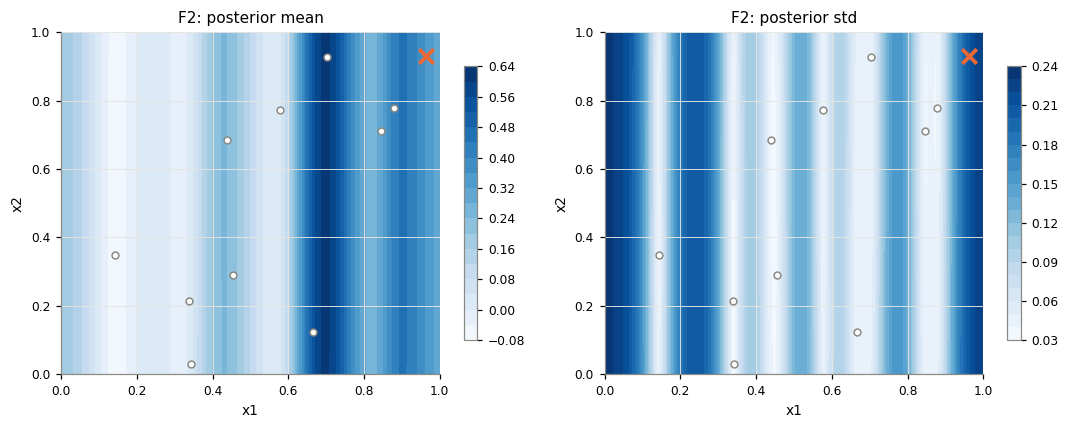

In [29]:
g = np.linspace(0, 1, 120); G = np.array(np.meshgrid(g, g)).reshape(2, -1).T
for i in [1, 2]:
    D, gp = DATA[i], MODELS[i]
    if gp is None:
        print(f"F{i}: exploration mode, no GP surface; proposed query {RESULTS[i]['query']}"); continue
    mu, sd = gp.predict(G, return_std=True)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, Z, t in zip(axes, [mu, sd], ["posterior mean", "posterior std"]):
        im = ax.contourf(g, g, Z.reshape(120, 120), levels=20, cmap="Blues")
        ax.scatter(D["X"][:, 0], D["X"][:, 1], s=20, color="white", edgecolor=GREY)
        ax.scatter(*RESULTS[i]["x"], marker="x", s=90, color=ORANGE, linewidth=2.5)
        ax.set(title=f"F{i}: {t}", xlabel="x1", ylabel="x2"); plt.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout(); plt.show()

## 9. Method comparison: five strategies for every function

To check that my conclusions don't depend on one model, I run four more strategies alongside the primary GP. **Every method sees exactly the same data.**

| Method | Surrogate | How it picks the point | Strengths | Weaknesses |
|---|---|---|---|---|
| **GP** (section 8) | Gaussian Process, ARD Matern 5/2 | EI or UCB over global and local candidates | Calibrated uncertainty; principled exploration | Assumes a smooth surface; struggles in high-D with few points |
| **TPE** | Kernel densities of "good" (top 25%) and "bad" inputs | Maximise l(x)/g(x): look like the good inputs, unlike the bad | Robust in higher dimensions; the standard in HPO tools | No explicit uncertainty; ignores the size of differences in output |
| **RF** | Extra-Trees ensemble (500 trees) | EI, using the spread between trees as the uncertainty | Handles jumps, thresholds and discrete inputs | Uncertainty is rough; cannot extrapolate beyond the data |
| **TuRBO** | GP, restricted to a trust region | EI inside a box around the best point, stretched by length-scale | Designed for high-D with small budgets; adapts to success | Local, so can miss a far-away better optimum |
| **Trend** | Linear regression | Step of 0.15 from the best point up the fitted gradient | Transparent, very cheap, a good baseline | Will overshoot or stall once the surface curves |

**TuRBO trust region.** The box starts with a side of 0.4. After each week I multiply it by 1.5 if that week improved the best (capped at 0.8), or by 0.7 if it didn't (floor 0.05). Each input's side is scaled by its GP length-scale, so the box is wider along inputs that matter less.

**F1 note.** F1's raw outputs are about 0 everywhere, so the comparison methods model **log10|y|** instead. The magnitude of the reading stands in for how close we are to a source, which gives the models a gradient to follow.

**Agreement.** For each function, I measure how far apart the five proposals are (mean pairwise distance ÷ √d, so 0 = identical and about 0.4 = as far apart as random points). I also find the **consensus** proposal: the medoid, the one closest to all the others.

In [30]:
from sklearn.ensemble import ExtraTreesRegressor
from scipy.special import logsumexp

METHODS = ["gp", "tpe", "rf", "turbo", "trend"]
MCOL = {"gp": "#2a78d6", "tpe": "#eb6834", "rf": "#1baf7a", "turbo": "#eda100", "trend": "#e87ba4"}
MMARK = {"gp": "o", "tpe": "s", "rf": "^", "turbo": "D", "trend": "v"}

def comparison_target(i, D, cfg):
    # F1 (explore mode): model log10|y| as a proximity signal; others: same transform as the GP
    if cfg.get("mode") == "explore":
        return np.log10(np.abs(D["y"]) + 1e-300)
    return transform(D["y"], cfg.get("tf", "none"))

def propose_tpe(X, t, rng, gamma=0.25, n_cand=5000):
    n, d = X.shape
    k = max(2, int(np.ceil(gamma * n)))
    order = np.argsort(-t); good, bad = X[order[:k]], X[order[k:]]
    bw = lambda P: np.clip(1.06 * P.std(0) * len(P) ** (-1 / (d + 4)), 0.03, 0.3)
    bg, bb = bw(good), bw(bad)
    cand = np.clip(good[rng.integers(0, k, n_cand)] + rng.normal(0, 1, (n_cand, d)) * bg, 0, UPPER)
    def logkde(Cn, P, b):
        z = (Cn[:, None, :] - P[None]) / b
        return logsumexp(-0.5 * (z ** 2).sum(2), axis=1) - np.log(len(P)) - np.log(b).sum()
    return cand[np.argmax(logkde(cand, good, bg) - logkde(cand, bad, bb))]

def propose_rf(X, t, rng, xi=0.01):
    rf = ExtraTreesRegressor(n_estimators=500, random_state=0).fit(X, t)
    cand = make_candidates(X, t, rng, n=20000)
    P = np.stack([e.predict(cand) for e in rf.estimators_])
    a = acquisition(P.mean(0), P.std(0), t.max(), "ei", xi, y_scale=np.std(t))
    return cand[a.argmax()]

def turbo_length(i, L0=0.4, grow=1.5, shrink=0.7, Lmax=0.8, Lmin=0.05):
    L = L0
    best = np.load(DATA_DIR / f"function_{i}" / "initial_outputs.npy").max()
    for w in sorted(HISTORY):
        yv = HISTORY[w].get(i, (None, None))[1]
        if yv is None:
            continue
        if yv > best:
            L, best = min(L * grow, Lmax), yv
        else:
            L = max(L * shrink, Lmin)
    return L

def propose_turbo(X, t, gp, rng, L, xi=0.01):
    d = X.shape[1]
    ls = gp.kernel_.k1.k2.length_scale
    w = np.clip(ls / np.exp(np.mean(np.log(ls))), 0.25, 4.0)
    half = np.minimum(L * w / 2, 0.5)
    c = X[t.argmax()]; lo, hi = np.clip(c - half, 0, 1), np.clip(c + half, 0, UPPER)
    cand = lo + rng.uniform(0, 1, (20000, d)) * (hi - lo)
    mu, sd = gp.predict(cand, return_std=True)
    return cand[acquisition(mu, sd, t.max(), "ei", xi, y_scale=np.std(t)).argmax()]

def propose_trend(X, t, step=0.15):
    lr = LinearRegression().fit(X, t)
    g = lr.coef_; g = g / (np.linalg.norm(g) + 1e-12)
    return np.clip(X[t.argmax()] + step * g, 0, UPPER), lr.score(X, t)

rng_cmp = np.random.default_rng(1000 + CURRENT_WEEK)   # separate stream: GP results above stay reproducible
PROPOSALS, CMP_GP, COMPARE = {}, {}, []
for i in range(1, N_FUNCS + 1):
    D, cfg = DATA[i], CONFIG[i]
    X, t = D["X"], comparison_target(i, D, cfg)
    gp_c = MODELS[i] if MODELS[i] is not None else fit_gp(X, t)
    CMP_GP[i] = gp_c
    L = turbo_length(i)
    trend_x, r2 = propose_trend(X, t)
    P = {"gp": RESULTS[i]["x"],
         "tpe": propose_tpe(X, t, rng_cmp),
         "rf": propose_rf(X, t, rng_cmp),
         "turbo": propose_turbo(X, t, gp_c, rng_cmp, L),
         "trend": trend_x}
    M = np.array([P[m] for m in METHODS])
    Dm = np.linalg.norm(M[:, None] - M[None], axis=2)
    P["consensus"] = M[Dm.sum(1).argmin()].copy()
    PROPOSALS[i] = P
    spread = Dm[np.triu_indices(len(METHODS), 1)].mean() / np.sqrt(D["d"])
    mu, sd = gp_c.predict(M, return_std=True)
    for m, x, mm, ss in zip(METHODS, M, mu, sd):
        COMPARE.append(dict(function=i, method=m, query=fmt_query(x),
                            gp_pred=mm, gp_sd=ss, dist_to_best=np.linalg.norm(x - X[t.argmax()])))
    COMPARE.append(dict(function=i, method=f"consensus = {METHODS[Dm.sum(1).argmin()]}",
                        query=fmt_query(P["consensus"]), gp_pred=np.nan, gp_sd=np.nan, dist_to_best=np.nan))
    RESULTS[i].update(spread=spread, turbo_L=L, trend_R2=r2)

cmp_df = pd.DataFrame(COMPARE).set_index(["function", "method"])
print("gp_pred / gp_sd are in the GP's modelling space (log(y) for F5, log10|y| for F1).")
cmp_df

gp_pred / gp_sd are in the GP's modelling space (log(y) for F5, log10|y| for F1).


query  gp_pred    gp_sd  dist_to_best
function method                                                                                              
1        gp                                                 0.419675-0.463269 -52.9120  32.5512        0.3174
         tpe                                                0.688446-0.854728 -38.3856   1.3689        0.1774
         rf                                                 0.602948-0.681199  -7.4862   9.3281        0.0472
         turbo                                              0.673527-0.619036  -8.8707  14.2012        0.0667
         trend                                              0.681911-0.828118 -32.1902   5.8560        0.1500
         consensus = rf                                     0.602948-0.681199      NaN      NaN           NaN
2        gp                                                 0.963166-0.929385   0.3545   0.2076        0.2605
         tpe                                                0.953188-0.000000   0.3728   0.1973        0.9598
         rf                                                 0.647849-0.954869   0.4362   0.0691        0.0617
         turbo                                              0.696050-0.433188   0.6090   0.0417        0.4934
         trend                                              0.852255-0.915872   0.3232   0.0400        0.1500
         consensus = trend                                  0.852255-0.915872      NaN      NaN           NaN
3        gp                                        0.233668-0.244902-0.000006  -0.0579   0.0842        0.5632
         tpe                                       0.183214-0.000000-0.405933  -0.0475   0.0522        0.6885
         rf                                        0.144569-0.474661-0.494488  -0.0499   0.0457        0.4046
         turbo                                     0.950363-0.972018-0.390130  -0.0433   0.0514        0.5848
         trend                                     0.545239-0.581897-0.202898  -0.1302   0.0191        0.1500
         consensus = trend                         0.545239-0.581897-0.202898      NaN      NaN           NaN
4        gp                               0.463911-0.402868-0.364200-0.420348  -1.8882   0.7526        0.2163
         tpe                              0.208365-0.000000-0.002796-0.207020 -16.5167   1.8053        0.7078
         rf                               0.582517-0.407672-0.338598-0.221787  -4.5537   0.4000        0.0939
         turbo                            0.422465-0.423014-0.383472-0.383305  -1.8138   0.7170        0.2097
         trend                            0.493571-0.356362-0.403232-0.150734  -5.2348   0.3897        0.1500
         consensus = turbo                0.422465-0.423014-0.383472-0.383305      NaN      NaN           NaN
5        gp                               0.100499-0.668722-0.946097-0.999999   7.8354   1.6795        0.2571
         tpe                              0.000100-0.999999-0.999999-0.920040   6.9390   1.5788        0.3001
         rf                               0.232458-0.839843-0.887381-0.802522   6.5352   0.4077        0.0771
         turbo                            0.030653-0.742805-0.988251-0.989608   7.8870   1.3532        0.2690
         trend                            0.199215-0.820798-0.963109-0.997778   7.7830   0.7906        0.1500
         consensus = trend                0.199215-0.820798-0.963109-0.997778      NaN      NaN           NaN
6        gp                      0.423548-0.129091-0.738806-0.897785-0.000000  -0.2322   0.2854        0.3718
         tpe                     0.692010-0.000000-0.922411-0.625809-0.000000  -0.6820   0.1957        0.2629
         rf                      0.900079-0.138935-0.834328-0.696732-0.047299  -1.2390   0.1853        0.2006
         turbo                   0.626609-0.247876-0.782636-0.927170-0.024514  -0.4128   0.1835        0.2773
         trend                   0.676612-0.096233-0.768335-0.767621-0.000000  -0.5661   0.1582        0.1263
  

### Where each method wants to go
Each panel is one function. The horizontal axis lists the inputs and the vertical axis gives the proposed value (0–1). Each coloured line is one method's proposal, and the grey line is the current best point. Lines that overlap mean the methods agree. Inputs where the lines fan out are where the landscape is still uncertain.

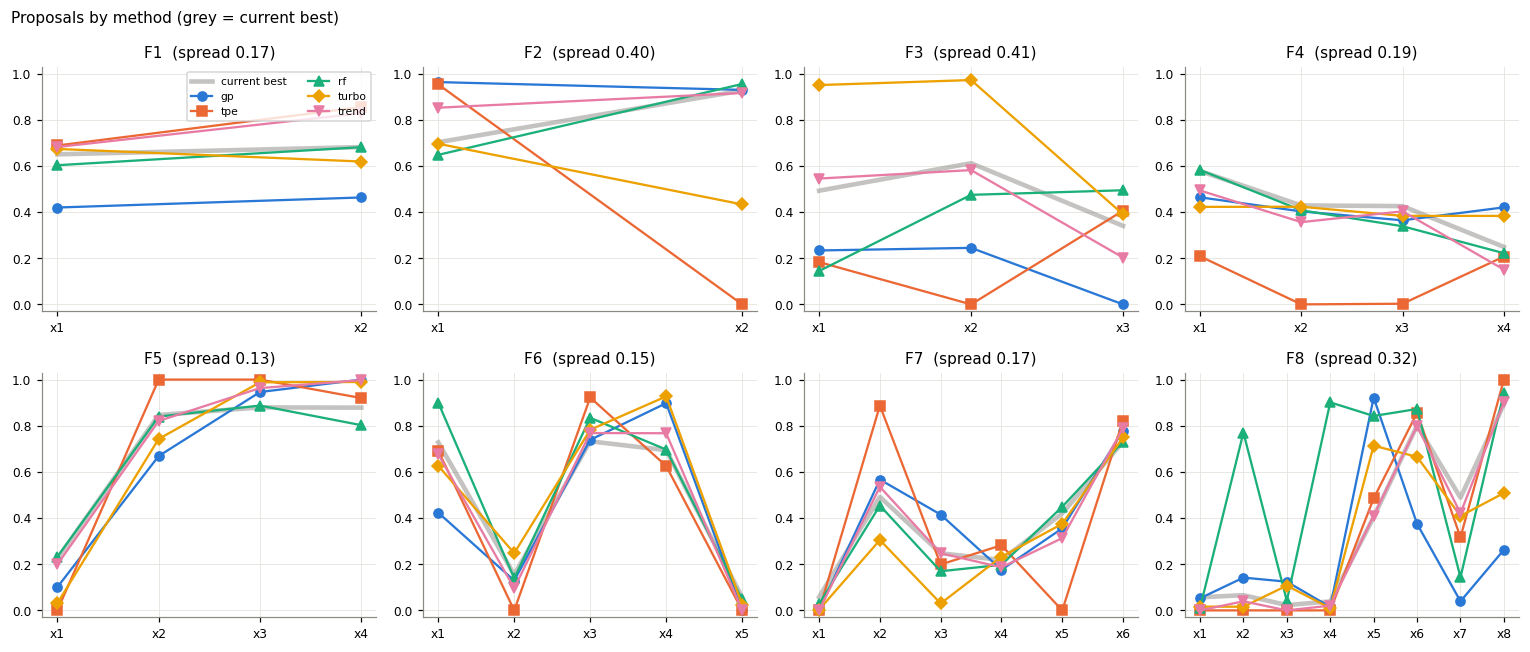

In [31]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, i in zip(axes.ravel(), range(1, 9)):
    d = DATA[i]["d"]; xs = np.arange(1, d + 1)
    best = DATA[i]["X"][comparison_target(i, DATA[i], CONFIG[i]).argmax()]
    ax.plot(xs, best, color=GREY, linewidth=3, alpha=0.5, label="current best")
    for m in METHODS:
        ax.plot(xs, PROPOSALS[i][m], color=MCOL[m], marker=MMARK[m], markersize=6, linewidth=1.5, label=m)
    ax.set(ylim=(-0.03, 1.03), xticks=xs, xticklabels=[f"x{k}" for k in xs],
           title=f"F{i}  (spread {RESULTS[i]['spread']:.2f})")
axes[0, 0].legend(fontsize=7, loc="upper right", ncol=2)
fig.suptitle("Proposals by method (grey = current best)", x=0.01, ha="left", fontsize=10)
plt.tight_layout(); plt.show()

### 2D functions: proposals on the surrogate surface
The background is the GP posterior mean that the comparison uses (for F1, log10|y|, so darker means closer to a source). White dots are observations and coloured markers are each method's proposal.

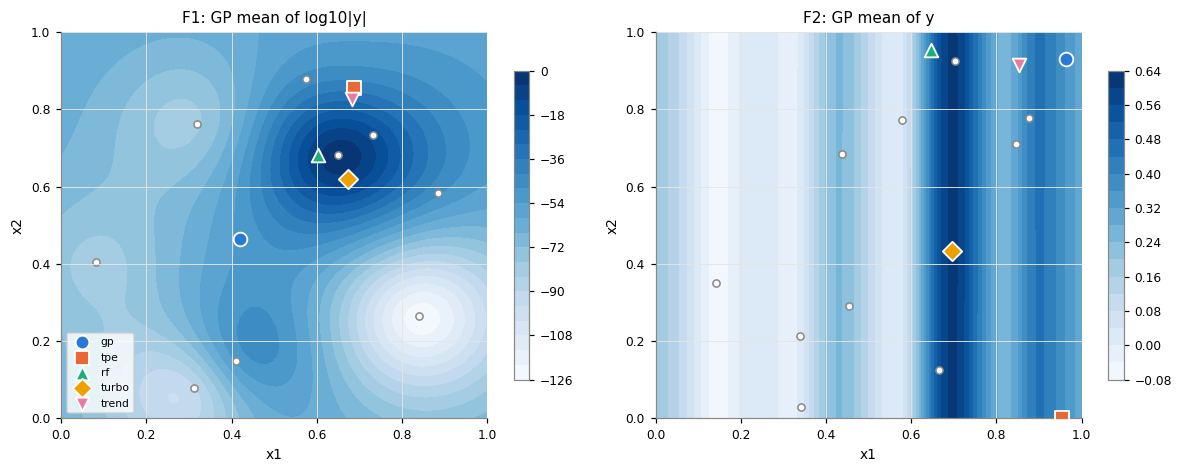

In [32]:
g = np.linspace(0, 1, 120); G = np.array(np.meshgrid(g, g)).reshape(2, -1).T
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, i in zip(axes, [1, 2]):
    im = ax.contourf(g, g, CMP_GP[i].predict(G).reshape(120, 120), levels=20, cmap="Blues")
    ax.scatter(DATA[i]["X"][:, 0], DATA[i]["X"][:, 1], s=22, color="white", edgecolor=GREY)
    for m in METHODS:
        ax.scatter(*PROPOSALS[i][m], marker=MMARK[m], s=80, color=MCOL[m], edgecolor="white", linewidth=1.2, label=m, zorder=3)
    ax.set(xlim=(0, 1), ylim=(0, 1), xlabel="x1", ylabel="x2",
           title=f"F{i}: " + ("GP mean of log10|y|" if i == 1 else "GP mean of y"))
    plt.colorbar(im, ax=ax, shrink=0.8)
axes[0].legend(fontsize=7, loc="lower left")
plt.tight_layout(); plt.show()

## 10. Final selection and portal submission

The table below applies my decision rule from section 0 and shows a **recommended** method for each function, with the reason. I then set `SELECT` myself. `"auto"` accepts the recommendation, or I can name a method: `"gp"`, `"tpe"`, `"rf"`, `"turbo"`, `"trend"` or `"consensus"`.

*Week 1 note: I submitted the Week 1 queries before building the comparison, so `SELECT` is set to `"gp"` for every function to match what went to the portal. From Week 2 I choose here.*

In [33]:
def recommend(i):
    D, cfg = DATA[i], CONFIG[i]
    if cfg.get("mode") == "explore" and np.abs(D["y"]).max() < cfg.get("signal_threshold", 0):
        return "gp", "no usable signal yet: keep space-filling (maximin)"
    if loo.get(i, np.nan) >= 0.7:
        return "gp", f"GP reliable (LOO {loo[i]:.2f})"
    if RESULTS[i]["spread"] < 0.15:
        return "consensus", f"GP moderate (LOO {loo[i]:.2f}) but methods agree (spread {RESULTS[i]['spread']:.2f})"
    return "turbo", f"GP moderate/weak (LOO {loo[i]:.2f}) and methods disagree (spread {RESULTS[i]['spread']:.2f}): stay local"

RECO = {i: recommend(i) for i in range(1, N_FUNCS + 1)}
pd.DataFrame([{"function": i, "recommended": RECO[i][0], "reason": RECO[i][1],
               "spread": RESULTS[i]["spread"], "LOO": loo.get(i), "TuRBO L": RESULTS[i]["turbo_L"]}
              for i in RECO]).set_index("function").round(3)

,recommended,reason,spread,LOO,TuRBO L
function,,,,,
1,gp,no usable signal yet: keep space-filling (maxi...,0.172,NaN,0.4
2,turbo,GP moderate/weak (LOO 0.41) and methods disagr...,0.395,0.406,0.4
3,turbo,GP moderate/weak (LOO 0.69) and methods disagr...,0.411,0.686,0.4
4,gp,GP reliable (LOO 0.97),0.186,0.973,0.4
5,consensus,GP moderate (LOO 0.23) but methods agree (spre...,0.127,0.229,0.4
6,consensus,GP moderate (LOO 0.55) but methods agree (spre...,0.147,0.549,0.4
7,turbo,GP moderate/weak (LOO 0.48) and methods disagr...,0.166,0.483,0.4
8,gp,GP reliable (LOO 0.98),0.323,0.983,0.4


In [34]:
# ---- my choice for this week ("auto" = accept recommendation) ----
# SELECT = {1: "gp", 2: "gp", 3: "gp", 4: "gp", 5: "gp", 6: "gp", 7: "gp", 8: "gp"}   # Week 1: as submitted
SELECT = {1: "auto", 2: "auto", 3: "auto", 4: "auto", 5: "auto", 6: "auto", 7: "auto", 8: "auto"}   # Week 2+ 

FINAL = {}

for i in range(1, N_FUNCS + 1):
    choice = RECO[i][0] if SELECT[i] == "auto" else SELECT[i]
    x = PROPOSALS[i][choice]
    q = fmt_query(x)
    assert len(parse_query(q)) == DATA[i]["d"] and all(0 <= v < 1 for v in parse_query(q))
    FINAL[i] = dict(function=i, method=choice, query=q,
                    followed_recommendation=(choice == RECO[i][0]))

print(f"=== WEEK {CURRENT_WEEK} QUERIES ===")
for i, f in FINAL.items():
    print(f"Function {i}: {f['query']}    [{f['method']}]")

pd.DataFrame(FINAL.values()).to_csv(DATA_DIR / f"week_{CURRENT_WEEK}_queries.csv", index=False)

print("\n# paste into HISTORY (section 2):")
print(f"    {CURRENT_WEEK}: {{")
for i, f in FINAL.items():
    print(f'        {i}: ("{f["query"]}", None),   # {f["method"]}')
print("    },")

=== WEEK 1 QUERIES ===
Function 1: 0.419675-0.463269    [gp]
Function 2: 0.963166-0.929385    [gp]
Function 3: 0.233668-0.244902-0.000006    [gp]
Function 4: 0.463911-0.402868-0.364200-0.420348    [gp]
Function 5: 0.100499-0.668722-0.946097-0.999999    [gp]
Function 6: 0.423548-0.129091-0.738806-0.897785-0.000000    [gp]
Function 7: 0.000000-0.566788-0.415090-0.175728-0.355442-0.779021    [gp]
Function 8: 0.052325-0.141964-0.124313-0.014745-0.921651-0.374929-0.039243-0.262463    [gp]

# paste into HISTORY (section 2):
    1: {
        1: ("0.419675-0.463269", None),   # gp
        2: ("0.963166-0.929385", None),   # gp
        3: ("0.233668-0.244902-0.000006", None),   # gp
        4: ("0.463911-0.402868-0.364200-0.420348", None),   # gp
        5: ("0.100499-0.668722-0.946097-0.999999", None),   # gp
        6: ("0.423548-0.129091-0.738806-0.897785-0.000000", None),   # gp
        7: ("0.000000-0.566788-0.415090-0.175728-0.355442-0.779021", None),   # gp
        8: ("0.052325-0.141964

## 11. Progress tracking

This shows the best value so far for each function, week by week. Week 0 is the best of the initial data. A flat line after several weeks is a signal to change strategy for that function.

In [35]:
weeks = sorted(w for w in HISTORY if any(HISTORY[w][f][1] is not None for f in HISTORY[w]))
prog = {}
for i in range(1, N_FUNCS + 1):
    y0 = np.load(DATA_DIR / f"function_{i}" / "initial_outputs.npy").max()
    best, series = y0, [y0]
    for w in weeks:
        yv = HISTORY[w].get(i, (None, None))[1]
        if yv is not None:
            best = max(best, yv)
        series.append(best)
    prog[f"F{i}"] = series
prog_df = pd.DataFrame(prog, index=[0] + weeks); prog_df.index.name = "week"

# weekly outcome: new result vs previous best (improvement = positive)
if weeks:
    fig, axes = plt.subplots(2, 4, figsize=(13, 5))
    for ax, (name, s) in zip(axes.ravel(), prog_df.items()):
        ax.plot(prog_df.index, s, color=BLUE, linewidth=2, marker="o", markersize=5)
        ax.set_title(name); ax.set_xlabel("week")
    fig.suptitle("Best value so far", x=0.01, ha="left", fontsize=10)
    plt.tight_layout(); plt.show()
else:
    print("No weekly outputs received yet. This section fills in once Week 1 results are added to HISTORY.")
prog_df.T

No weekly outputs received yet. This section fills in once Week 1 results are added to HISTORY.


week,0
F1,7.7109e-16
F2,6.1121e-01
F3,-3.4835e-02
F4,-4.0255e+00
F5,1.0889e+03
F6,-7.1426e-01
F7,1.3650e+00
F8,9.5985e+00


## 12. Conclusions and weekly reflection

### My overall approach
- I use a **GP surrogate with an acquisition function** as my core method, because every evaluation is expensive and the GP gives me calibrated uncertainty.
- I **set the strategy per function**: each description and dataset decides the output transform, acquisition function, exploration level and trust region.
- I **cross-check every week with four alternative strategies** (TPE, Random Forest, TuRBO, trend-following). How much they agree tells me how much to trust the proposal, and my submission follows a transparent decision rule that I can override with a stated reason.
- I **use simple models as sanity checks.** When the GP and the simple trends disagree (as for F5 in Week 1), I constrain the search rather than follow an extrapolation.
- I **move from exploring to exploiting over time**, adjusted per function to its own results.

### My current conclusions (Week 1: before any results)
| F | Status | Next-step hypothesis |
|---|---|---|
| 1 | No signal found yet | Space-filling. If the centre is also 0, probe near (0.65, 0.68), where the only non-zero reading is |
| 2 | Best 0.611 at (0.70, 0.93) | Test the high-x1 edge. If it is weak, return to the neighbourhood of the best point |
| 3 | Best -0.035 | Check whether x3 → 0 keeps improving (a boundary optimum) |
| 4 | Best -4.03, central (GP strong, LOO 0.97) | Local refinement. GP predicts about -1.9 |
| 5 | Best 1089 (GP weak, LOO 0.23) | Push x3 and x4 higher within the trust region (unimodal peak probably near the upper corner) |
| 6 | Best -0.714 | Follow the low-x5, high-x3/x4 trend |
| 7 | Best 1.365 (one outlier) | Refine around the single strong point |
| 8 | Best 9.60 (GP strong, LOO 0.98) | Exploit the linear trend: low x1, x3 and x7 |

### Reflection template (copy one block per week)
> **Week N**
> - **Method:** what model and acquisition function were used, and any changes from last week and why.
> - **Exploration vs exploitation:** which functions explored and which exploited, and why.
> - **Method comparison:** where the five methods agreed or disagreed, which one I submitted, and whether I overrode the recommendation (and why).
> - **What the results showed:** for each function, whether it improved or not, and what that says about the function's shape (boundary optimum, narrow peak, noise, irrelevant inputs).
> - **Strategy for next round:** the setting changes I'll make in `CONFIG` and my reasoning.

### Reflection log

**Week 1:** see `week1_reflection.md`. In short, I used a GP (Matern 5/2, ARD) with EI or UCB for each function, maximin exploration for F1, and a log transform with a trust region for F5. I leaned towards exploring for F1 and F2 and exploiting for F4, F5 and F7. I built the five-method comparison after submitting, so from Week 2 I will use it to choose each query.

**Week 2:** *(write after Week 1 results arrive)*